### This code is a mess, somwhere at the bottom should be the most up to date code that produces most up2date results

In [1]:
import pandas as pd
import numpy as np
import subprocess
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline, FeatureUnion 

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve
from gtda.pipeline import make_pipeline

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = 'type' 
if target_col not in df.columns:
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Data shape: {X.shape}")
print(f"Found subtypes: {le.classes_}")

Data shape: (151, 54676)
Found subtypes: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve
from gtda.pipeline import make_pipeline
from sklearn.pipeline import FeatureUnion, make_pipeline as make_sklearn_pipeline
from sklearn.preprocessing import FunctionTransformer

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = 'type' 
if target_col not in df.columns:
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_features_to_keep = 3000
selector = SelectKBest(score_func=f_classif, k=n_features_to_keep)
X_reduced = selector.fit_transform(X_scaled, y_encoded)

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape for TDA: {X_reduced.shape}")

embedding_dimension = 3
embedding_time_delay = 1
homology_dimensions = [0, 1] 

embedder = SingleTakensEmbedding(
    parameters_type="fixed",
    n_jobs=-1,
    time_delay=embedding_time_delay,
    dimension=embedding_dimension
)

X_embedded = [embedder.fit_transform(x) for x in X_reduced]

VR = VietorisRipsPersistence(homology_dimensions=homology_dimensions, n_jobs=-1)

flattener = FunctionTransformer(lambda X: X.reshape(X.shape[0], -1))

tda_features = FeatureUnion([
    ("landscape", make_sklearn_pipeline(
        PersistenceLandscape(n_bins=100), 
        flattener
    )),
    
    ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
    ("amplitude_bottleneck", Amplitude(metric="bottleneck")),
    
    ("betti", make_sklearn_pipeline(
        BettiCurve(n_bins=100), 
        flattener
    ))
])

tda_pipeline = make_pipeline(VR, tda_features)

print("Computing Rips complexes and extracting features...")
X_tda = tda_pipeline.fit_transform(X_embedded)
print(f"Shape of topological features: {X_tda.shape}")
X_train, X_test, y_train, y_test = train_test_split(
    X_tda, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n=== Classification Report (Topological Features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Original shape: (151, 54676)
Reduced shape for TDA: (151, 3000)
Computing Rips complexes and extracting features...
Shape of topological features: (151, 404)

=== Classification Report (Topological Features) ===
Accuracy: 0.4783

              precision    recall  f1-score   support

         HER       0.57      0.44      0.50         9
       basal       0.41      0.54      0.47        13
   cell_line       0.80      1.00      0.89         4
   luminal_A       0.44      0.44      0.44         9
   luminal_B       0.29      0.22      0.25         9
      normal       1.00      0.50      0.67         2

    accuracy                           0.48        46
   macro avg       0.59      0.52      0.54        46
weighted avg       0.48      0.48      0.47        46



In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = 'type' 
if target_col not in df.columns:
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
flattener = FunctionTransformer(lambda X: X.reshape(X.shape[0], -1))

tda_features = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=100)), 
        ("flatten", flattener)
    ])),
    ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=100)), 
        ("flatten", flattener)
    ]))
])

full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

print(f"Dataset summary: {X.shape[0]} samples, {X.shape[1]} features.")
print("Evaluating the topological pipeline with Stratified 3-Fold Cross-Validation...")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    full_pipeline, X, y_encoded, 
    cv=cv, 
    scoring=('accuracy', 'f1_macro'),
    n_jobs=1, 
    return_train_score=False
)

print(f"\n=== Cross-Validation Results ===")
print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"Mean CV F1-Macro: {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")

Dataset summary: 151 samples, 54676 features.
Evaluating the topological pipeline with Stratified 3-Fold Cross-Validation...

=== Cross-Validation Results ===
Mean CV Accuracy: 0.5034 (+/- 0.0419)
Mean CV F1-Macro: 0.5257 (+/- 0.0597)


In [4]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'embedding__time_delay': [1, 2, 3],
    'embedding__dimension': [2, 3, 4],
}

print("Starting Grid Search to find optimal Takens parameters without guessing...")

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1, 
    verbose=2
)

grid_search.fit(X, y_encoded)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Starting Grid Search to find optimal Takens parameters without guessing...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


[CV] END ....embedding__dimension=2, embedding__time_delay=1; total time= 3.2min
[CV] END ....embedding__dimension=2, embedding__time_delay=1; total time= 2.3min


KeyboardInterrupt: 

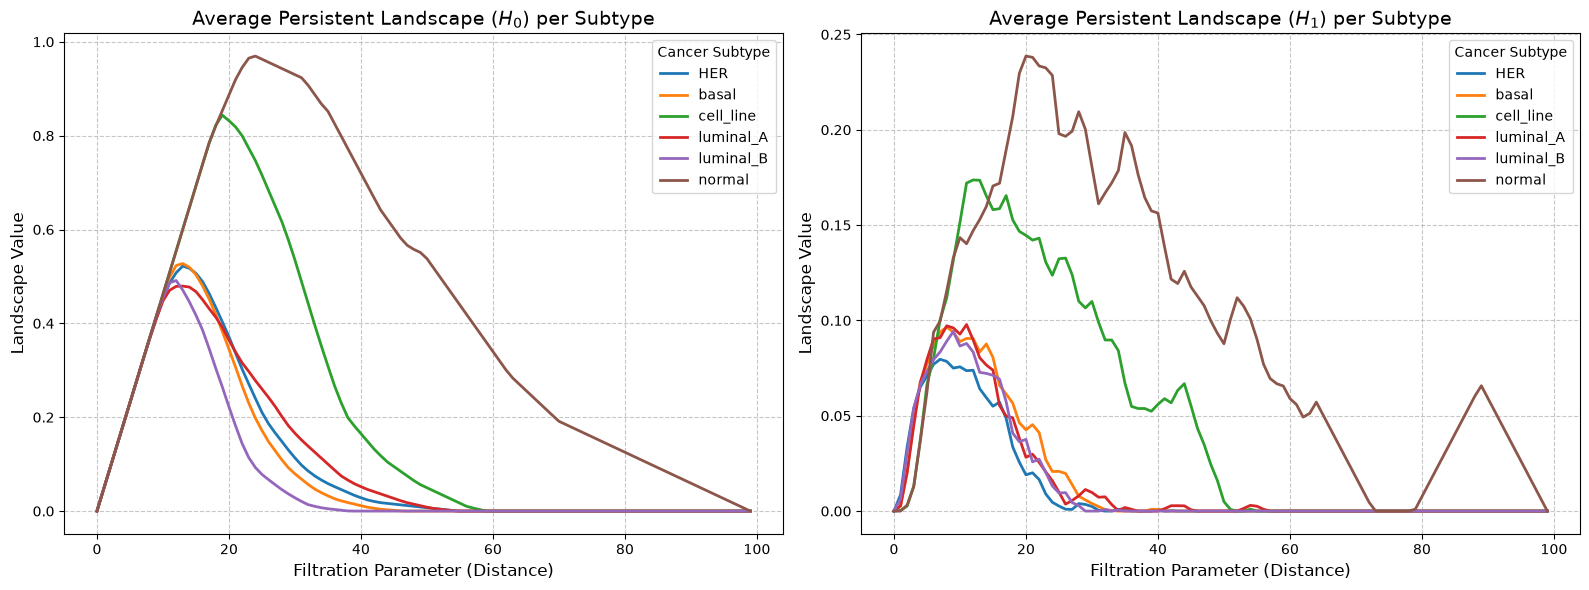

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

optimal_embedder = TakensEmbedding(time_delay=3, dimension=3)
X_embedded_opt = optimal_embedder.fit_transform(X_reduced)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams = rips.fit_transform(X_embedded_opt)

landscape_extractor = PersistenceLandscape(n_bins=100)
landscapes = landscape_extractor.fit_transform(diagrams)

homology_dims = [0, 1]
classes = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(classes):
    sample_indices = np.where(y_encoded == class_idx)[0]
    
    class_landscapes = landscapes[sample_indices]
    
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

axes[0].set_title('Average Persistent Landscape ($H_0$) per Subtype', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].set_title('Average Persistent Landscape ($H_1$) per Subtype', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from ripser import ripser 

class CustomRipserTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, maxdim=1, thresh=np.inf):
        self.maxdim = maxdim
        self.thresh = thresh

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        diagrams_list = []
        
        for point_cloud in X:
            res = ripser(point_cloud, maxdim=self.maxdim, thresh=self.thresh)
            dgms = res['dgms']
            
            sample_dgm = []
            for dim, dgm in enumerate(dgms):
                if len(dgm) > 0:
                    dim_col = np.full((dgm.shape[0], 1), dim)
                    dgm_with_dim = np.hstack([dgm, dim_col])
                    sample_dgm.append(dgm_with_dim)
            
            if len(sample_dgm) > 0:
                diagrams_list.append(np.vstack(sample_dgm))
            else:
                diagrams_list.append(np.empty((0, 3)))
        
        max_points = max([len(dgm) for dgm in diagrams_list]) if diagrams_list else 0
        
        padded_diagrams = np.zeros((len(X), max_points, 3))
        
        for i, dgm in enumerate(diagrams_list):
            n_points = len(dgm)
            if n_points > 0:
                padded_diagrams[i, :n_points, :] = dgm
                
        return padded_diagrams

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

def calculate_ami_continuous(x, y, bins=50):
    H, _, _ = np.histogram2d(x, y, bins=bins)
    return mutual_info_score(None, None, contingency=H)

def find_optimal_tau_via_ami(X, max_tau=20, bins=50):
    mean_amis = []
    
    for tau in range(1, max_tau + 1):
        amis_for_tau = []
        for sample in X:
            x_t = sample[:-tau]
            x_t_plus_tau = sample[tau:]
            
            ami = calculate_ami_continuous(x_t, x_t_plus_tau, bins=bins)
            amis_for_tau.append(ami)
            
        mean_amis.append(np.mean(amis_for_tau))
        
    mean_amis = np.array(mean_amis)
    
    diffs = np.diff(mean_amis)
    local_mins = np.where(diffs > 0)[0] 
    
    if len(local_mins) > 0:
        # +1 because tau starts at 1
        optimal_tau = local_mins[0] + 1 
        print(f"First local minimum found at tau = {optimal_tau}")
    else:
        optimal_tau = np.argmin(mean_amis) + 1
        print(f"No local minimum found. Taking global minimum at tau = {optimal_tau}")
        
    return optimal_tau, mean_amis


selector = SelectKBest(score_func=f_classif, k=3000)
X_reduced_for_ami = selector.fit_transform(StandardScaler().fit_transform(X), y_encoded)

print("Calculating optimal time delay using Average Mutual Information...")
optimal_tau, ami_values = find_optimal_tau_via_ami(X_reduced_for_ami, max_tau=60)

Calculating optimal time delay using Average Mutual Information...
First local minimum found at tau = 4


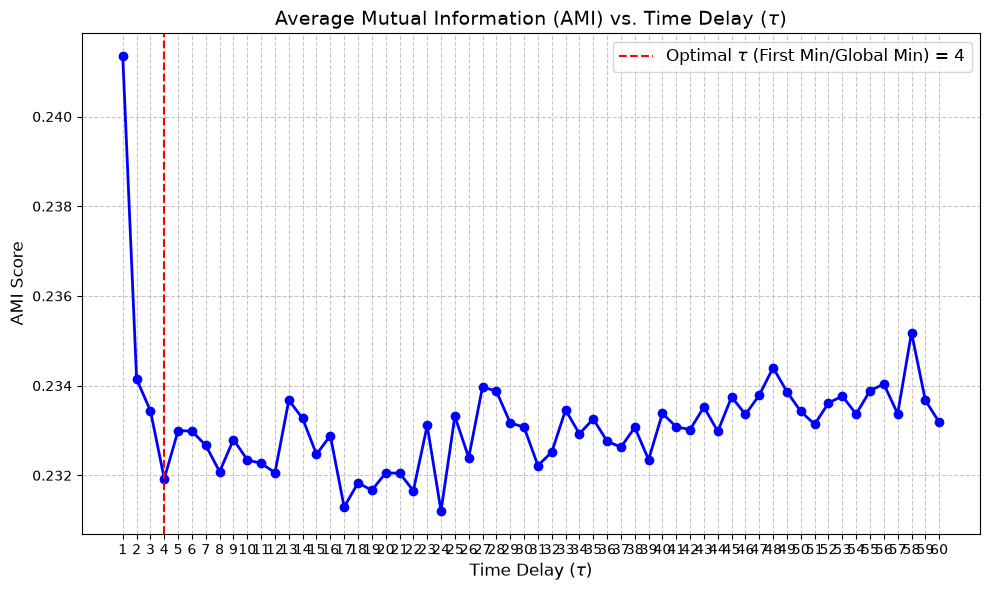


Evaluating pipeline using native VietorisRipsPersistence with fixed tau=4...


KeyboardInterrupt: 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

optimal_tau = int(optimal_tau)

tau_values = range(1, len(ami_values) + 1)

plt.figure(figsize=(10, 6))
plt.plot(tau_values, ami_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.axvline(x=optimal_tau, color='r', linestyle='--', 
            label=f'Optimal $\\tau$ (First Min/Global Min) = {optimal_tau}')

plt.title('Average Mutual Information (AMI) vs. Time Delay ($\\tau$)', fontsize=14)
plt.xlabel('Time Delay ($\\tau$)', fontsize=12)
plt.ylabel('AMI Score', fontsize=12)
plt.xticks(tau_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


bin_resolutions = [10, 50, 100, 200]
results_n_bins = {}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

print(f"\nEvaluating pipeline using native VietorisRipsPersistence with fixed tau={optimal_tau}...")

for bins in bin_resolutions:
    tda_features = FeatureUnion([
        ("landscape", Pipeline([
            ("extract", PersistenceLandscape(n_bins=bins)), 
            ("flatten", flattener)
        ])),
        ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
        ("betti", Pipeline([
            ("extract", BettiCurve(n_bins=bins)), 
            ("flatten", flattener)
        ]))
    ])

    full_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
        ('embedding', TakensEmbedding(time_delay=optimal_tau, dimension=3)),
        
        ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        
        ('tda_features', tda_features),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
    ])

    try:
        cv_results = cross_validate(
            full_pipeline, X, y_encoded, 
            cv=cv, 
            scoring=('accuracy', 'f1_macro'),
            n_jobs=1,
            return_train_score=True 
        )
        
        mean_test_acc = np.mean(cv_results['test_accuracy'])
        mean_train_acc = np.mean(cv_results['train_accuracy'])
        
        results_n_bins[bins] = mean_test_acc
        
        print(f"n_bins = {bins:3d} | Test Accuracy: {mean_test_acc:.4f} | Train Accuracy: {mean_train_acc:.4f}")
        
    except Exception as e:
        print(f"n_bins = {bins:3d} | Failed with error: {e}")

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

print("Evaluating Baseline Random Forest (No TDA)...")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_results = cross_validate(
    baseline_pipeline, X, y_encoded, 
    cv=cv, scoring=('accuracy', 'f1_macro')
)

print(f"Baseline Accuracy: {np.mean(baseline_results['test_accuracy']):.4f}")
print(f"Baseline F1-Macro: {np.mean(baseline_results['test_f1_macro']):.4f}")

Evaluating Baseline Random Forest (No TDA)...
Baseline Accuracy: 0.9271
Baseline F1-Macro: 0.9256


In [10]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.decomposition import PCA

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

class SingleSampleNetworkTopology(BaseEstimator, TransformerMixin):
    def __init__(self, n_active_genes=100, embedding_dim=3):
        self.n_active_genes = n_active_genes
        self.embedding_dim = embedding_dim
        self.gene_coords_ = None

    def fit(self, X, y=None):
        corr = np.corrcoef(X.T + np.random.normal(0, 1e-8, X.T.shape))
        corr = np.nan_to_num(corr, nan=0.0)
        
        dist_matrix = 1 - np.abs(corr)
    
        pca = PCA(n_components=self.embedding_dim, random_state=42)
        self.gene_coords_ = pca.fit_transform(dist_matrix)
        
        return self

    def transform(self, X, y=None):
        point_clouds = []
        
        for sample in X:
            top_gene_indices = np.argsort(sample)[-self.n_active_genes:]
            
            patient_cloud = self.gene_coords_[top_gene_indices]
            point_clouds.append(patient_cloud)
            
        return np.array(point_clouds)

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_features = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=1000)),
    ('ssn_topology', SingleSampleNetworkTopology(n_active_genes=100, embedding_dim=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1))
])

print("Evaluating Single-Sample Network Topology with Stratified 3-Fold CV...")

cv = StratifiedKFold(n_splits=3, shuffle=True)

cv_results = cross_validate(
    full_pipeline, X, y_encoded, 
    cv=cv, 
    scoring=('accuracy', 'f1_macro'),
    n_jobs=1,
    return_train_score=False
)

print(f"\n=== Topological Network Classifier Results ===")
print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"Mean CV F1-Macro: {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")

Evaluating Single-Sample Network Topology with Stratified 3-Fold CV...

=== Topological Network Classifier Results ===
Mean CV Accuracy: 0.6559 (+/- 0.0472)
Mean CV F1-Macro: 0.6137 (+/- 0.0763)


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

tda_branch = Pipeline([
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])


raw_branch = FunctionTransformer(lambda X: X)

combined_features = FeatureUnion([
    ('raw_genes', raw_branch), 
    ('tda_topology', tda_branch) 
])

enriched_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=1000)),
    ('feature_fusion', combined_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=3000)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

embedder = TakensEmbedding(time_delay=4, dimension=3)
X_embedded_consistent = embedder.fit_transform(X_reduced_consistent)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_consistent = rips.fit_transform(X_embedded_consistent)

landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_consistent = landscape_extractor.fit_transform(diagrams_consistent)

homology_dims = [0, 1]
classes = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(classes):
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_consistent[sample_indices]
    
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

axes[0].set_title('Average Persistent Landscape ($H_0$) - Pipeline Matched', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].set_title('Average Persistent Landscape ($H_1$) - Pipeline Matched', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=-1)

y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=-1)

print("=== Baseline (Raw Genes) ===")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print("\n=== Enriched Pipeline (Raw Genes + TDA) ===")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

KeyboardInterrupt: 

In [ ]:
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=-1)
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

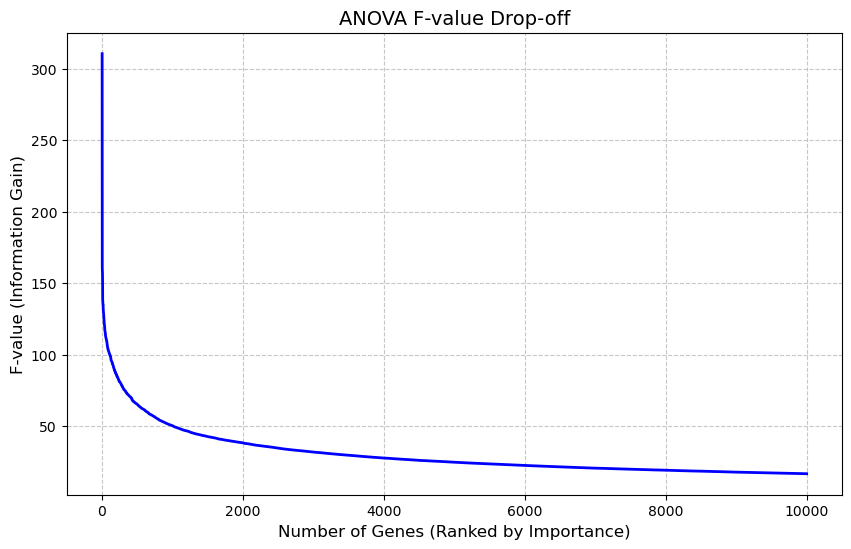


=== Statistical Feature Selection Results ===
Total original genes: 54676
Genes with TRUE statistical significance (FDR alpha=0.01): 45073
Percentage of useful genome: 82.44%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import f_classif, SelectFdr

df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

f_values, p_values = f_classif(X_scaled, y_encoded)

f_values_sorted = np.sort(f_values)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10001), f_values_sorted[:10000], linewidth=2, color='blue')
plt.title('ANOVA F-value Drop-off', fontsize=14)
plt.xlabel('Number of Genes (Ranked by Importance)', fontsize=12)
plt.ylabel('F-value (Information Gain)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('f_value_elbow_plot.png', dpi=300)
plt.show()


fdr_selector = SelectFdr(score_func=f_classif, alpha=0.01)
X_fdr_selected = fdr_selector.fit_transform(X_scaled, y_encoded)

genes_kept_mask = fdr_selector.get_support()
n_genes_kept = np.sum(genes_kept_mask)

print(f"\n=== Statistical Feature Selection Results ===")
print(f"Total original genes: {X_scaled.shape[1]}")
print(f"Genes with TRUE statistical significance (FDR alpha=0.01): {n_genes_kept}")
print(f"Percentage of useful genome: {(n_genes_kept / X_scaled.shape[1]) * 100:.2f}%")

# CLEAR CODE BELOW

#### Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report, accuracy_score

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

#### Data Loading and Preparation

In [15]:
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

N_GENES = 3000 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#### Baseline Pipeline (Raw Genes Only)

In [16]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

#### Enriched Pipeline (Raw Genes + TDA)


In [18]:
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

tda_branch = Pipeline([
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])

raw_branch = FunctionTransformer(lambda X: X)

combined_features = FeatureUnion([
    ('raw_genes', raw_branch),
    ('tda_topology', tda_branch) 
])

enriched_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('feature_fusion', combined_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])


#### Evaluation and Reporting

In [20]:

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} original genes.")
print(f"Comparing models using top {N_GENES} genes...\n")

print("Generating out-of-fold predictions for Baseline Pipeline...")
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=1)

print("Generating out-of-fold predictions for Enriched Pipeline...")
y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=1)

print(" BASELINE PIPELINE REPORT (RAW GENES ONLY)")
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_baseline):.4f}\n")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print(" ENRICHED PIPELINE REPORT (RAW GENES + TDA)")
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_enriched):.4f}\n")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

Dataset shape: 151 samples, 54676 original genes.
Comparing models using top 3000 genes...

Generating out-of-fold predictions for Baseline Pipeline...
Generating out-of-fold predictions for Enriched Pipeline...


KeyboardInterrupt: 

#### Exact Preprocessing from the Pipeline

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

#### Exact TDA Extraction (time_delay=4, dim=3, bins=50)

In [ ]:
embedder = TakensEmbedding(time_delay=4, dimension=3)
X_embedded_consistent = embedder.fit_transform(X_reduced_consistent)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_consistent = rips.fit_transform(X_embedded_consistent)

landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_consistent = landscape_extractor.fit_transform(diagrams_consistent)

Extracting TDA features for 3000 genes...


#### Calculate Mean Landscapes and Plot

Plotting Fréchet means of Persistence Landscapes...


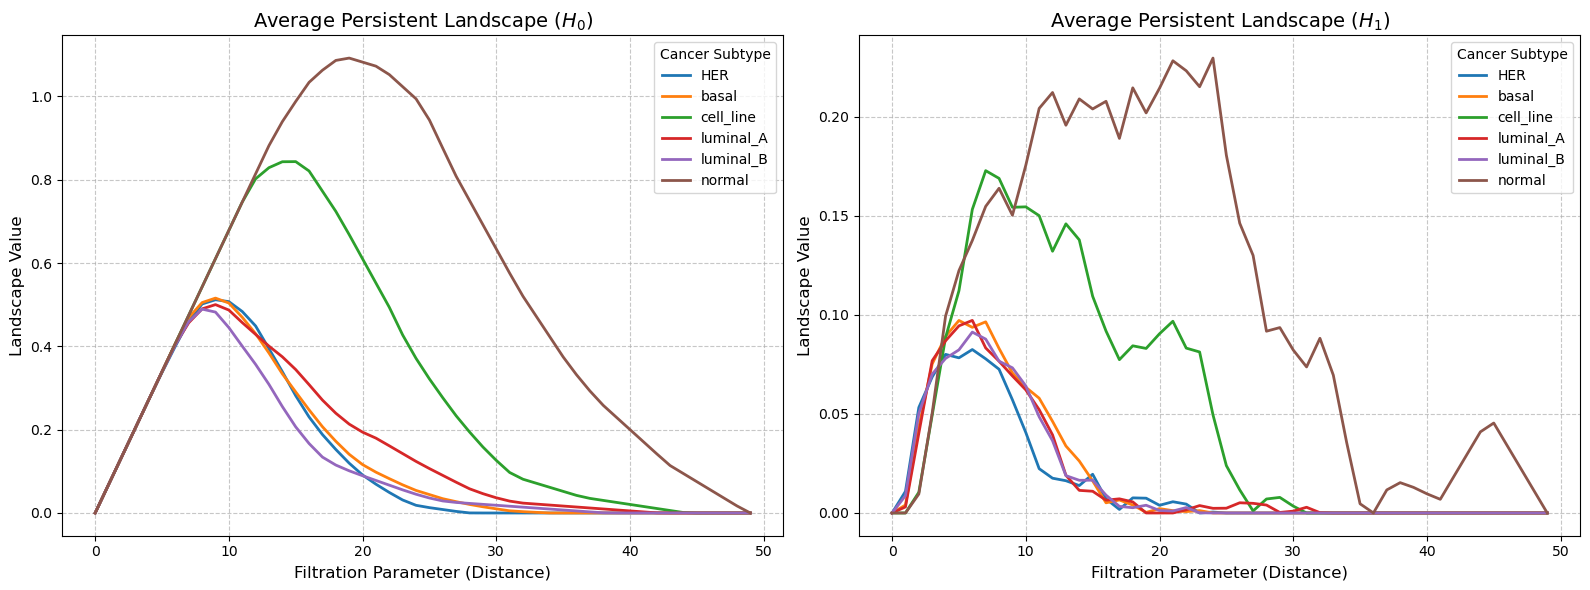

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(le.classes_):
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_consistent[sample_indices]
    
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

axes[0].set_title('Average Persistent Landscape ($H_0$)', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].set_title('Average Persistent Landscape ($H_1$)', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/average_persistence_landscapes_{N_GENES}genes.png', dpi=300)
plt.show()

# FINAL WORKFLOW

In [ ]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve


class SingleSampleNetworkTopology(BaseEstimator, TransformerMixin):
    def __init__(self, n_active_genes=100, embedding_dim=3):
        self.n_active_genes = n_active_genes
        self.embedding_dim = embedding_dim
        self.gene_coords_ = None

    def fit(self, X, y=None):
        corr = np.corrcoef(X.T + np.random.normal(0, 1e-8, X.T.shape))
        corr = np.nan_to_num(corr, nan=0.0)
        
        dist_matrix = 1 - np.abs(corr)
        
        pca = PCA(n_components=self.embedding_dim, random_state=42)
        self.gene_coords_ = pca.fit_transform(dist_matrix)
        
        return self

    def transform(self, X, y=None):
        point_clouds = []
        
        for sample in X:
            top_gene_indices = np.argsort(sample)[-self.n_active_genes:]
            
            patient_cloud = self.gene_coords_[top_gene_indices]
            point_clouds.append(patient_cloud)
            
        return np.array(point_clouds)

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

N_GENES = 3000 
N_A_GENES = 500
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

tda_branch = Pipeline([
    ('ssn_topology', SingleSampleNetworkTopology(n_active_genes=N_A_GENES, embedding_dim=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])

raw_branch = FunctionTransformer(lambda X: X)

combined_features = FeatureUnion([
    ('raw_genes', raw_branch),   
    ('tda_topology', tda_branch)
])

enriched_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('feature_fusion', combined_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])


print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} original genes.")
print(f"Comparing models using top {N_GENES} genes with Single-Sample Network Topology...\n")

print("Generating out-of-fold predictions for Baseline Pipeline...")
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=1)

print("Generating out-of-fold predictions for Enriched Pipeline...")
y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=1)

print(" BASELINE PIPELINE REPORT (RAW GENES ONLY)")
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_baseline):.4f}\n")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print(" ENRICHED PIPELINE REPORT (GENES + NETWORK TDA)")
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_enriched):.4f}\n")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

Dataset shape: 151 samples, 54676 original genes.
Comparing models using top 3000 genes with Single-Sample Network Topology...

Generating out-of-fold predictions for Baseline Pipeline...
Generating out-of-fold predictions for Enriched Pipeline...

 BASELINE PIPELINE REPORT (RAW GENES ONLY)
Global Accuracy: 0.9272

              precision    recall  f1-score   support

         HER       0.93      0.93      0.93        30
       basal       0.95      0.95      0.95        41
   cell_line       1.00      1.00      1.00        14
   luminal_A       0.87      0.90      0.88        29
   luminal_B       0.90      0.90      0.90        30
      normal       1.00      0.86      0.92         7

    accuracy                           0.93       151
   macro avg       0.94      0.92      0.93       151
weighted avg       0.93      0.93      0.93       151


 ENRICHED PIPELINE REPORT (GENES + NETWORK TDA)
Global Accuracy: 0.9669

              precision    recall  f1-score   support

         HE


 GENERATING TOPOLOGICAL VISUALIZATIONS (NETWORK TDA)
Building Patient-Specific Networks for 3000 genes...
Calculating Vietoris-Rips persistence...
Plotting Fréchet means of Persistence Landscapes...


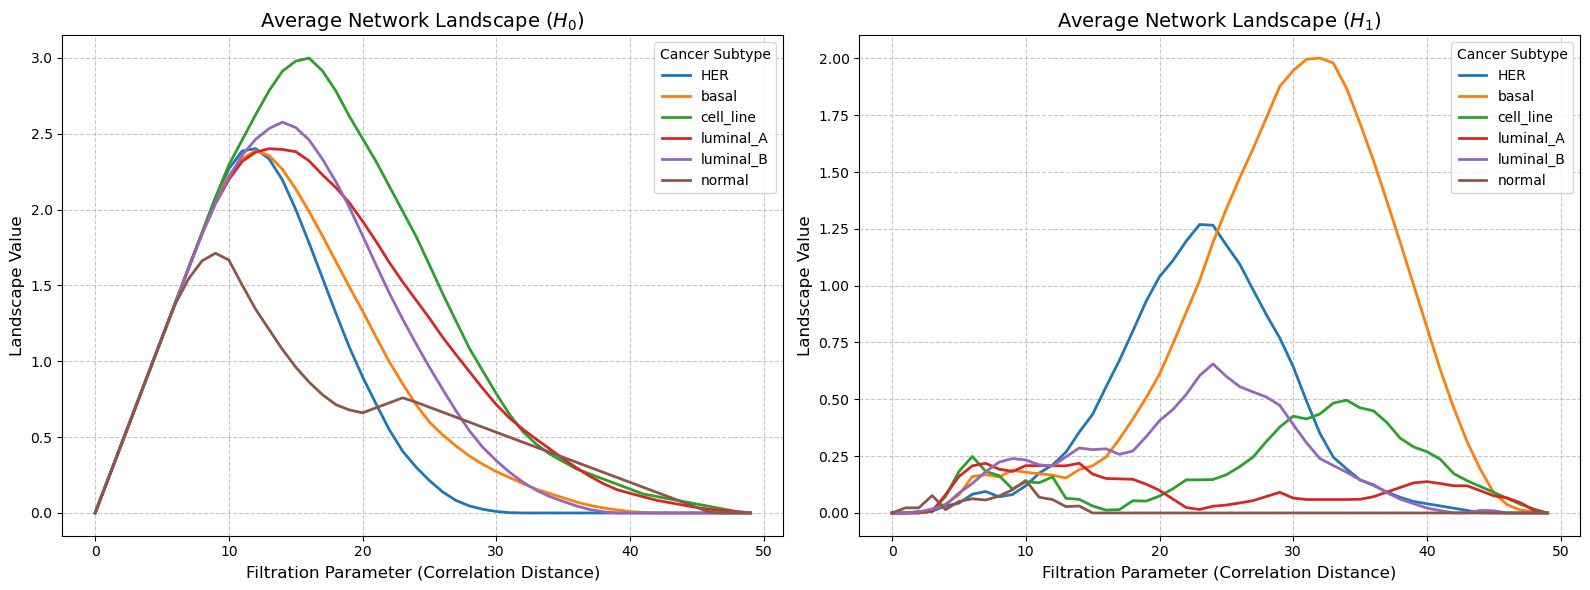

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

network_topology = SingleSampleNetworkTopology(n_active_genes=100, embedding_dim=3)

X_point_clouds = network_topology.fit_transform(X_reduced_consistent)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_network = rips.fit_transform(X_point_clouds)

landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_network = landscape_extractor.fit_transform(diagrams_network)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(le.classes_):
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_network[sample_indices]
    
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

axes[0].set_title('Average Network Landscape ($H_0$)', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Correlation Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].set_title('Average Network Landscape ($H_1$)', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Correlation Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/500_better_average_network_landscapes_{N_GENES}genes.png', dpi=300)
plt.show()


 EXTRACTING RANDOM FOREST FEATURE IMPORTANCES
Fitting the model on the full dataset...


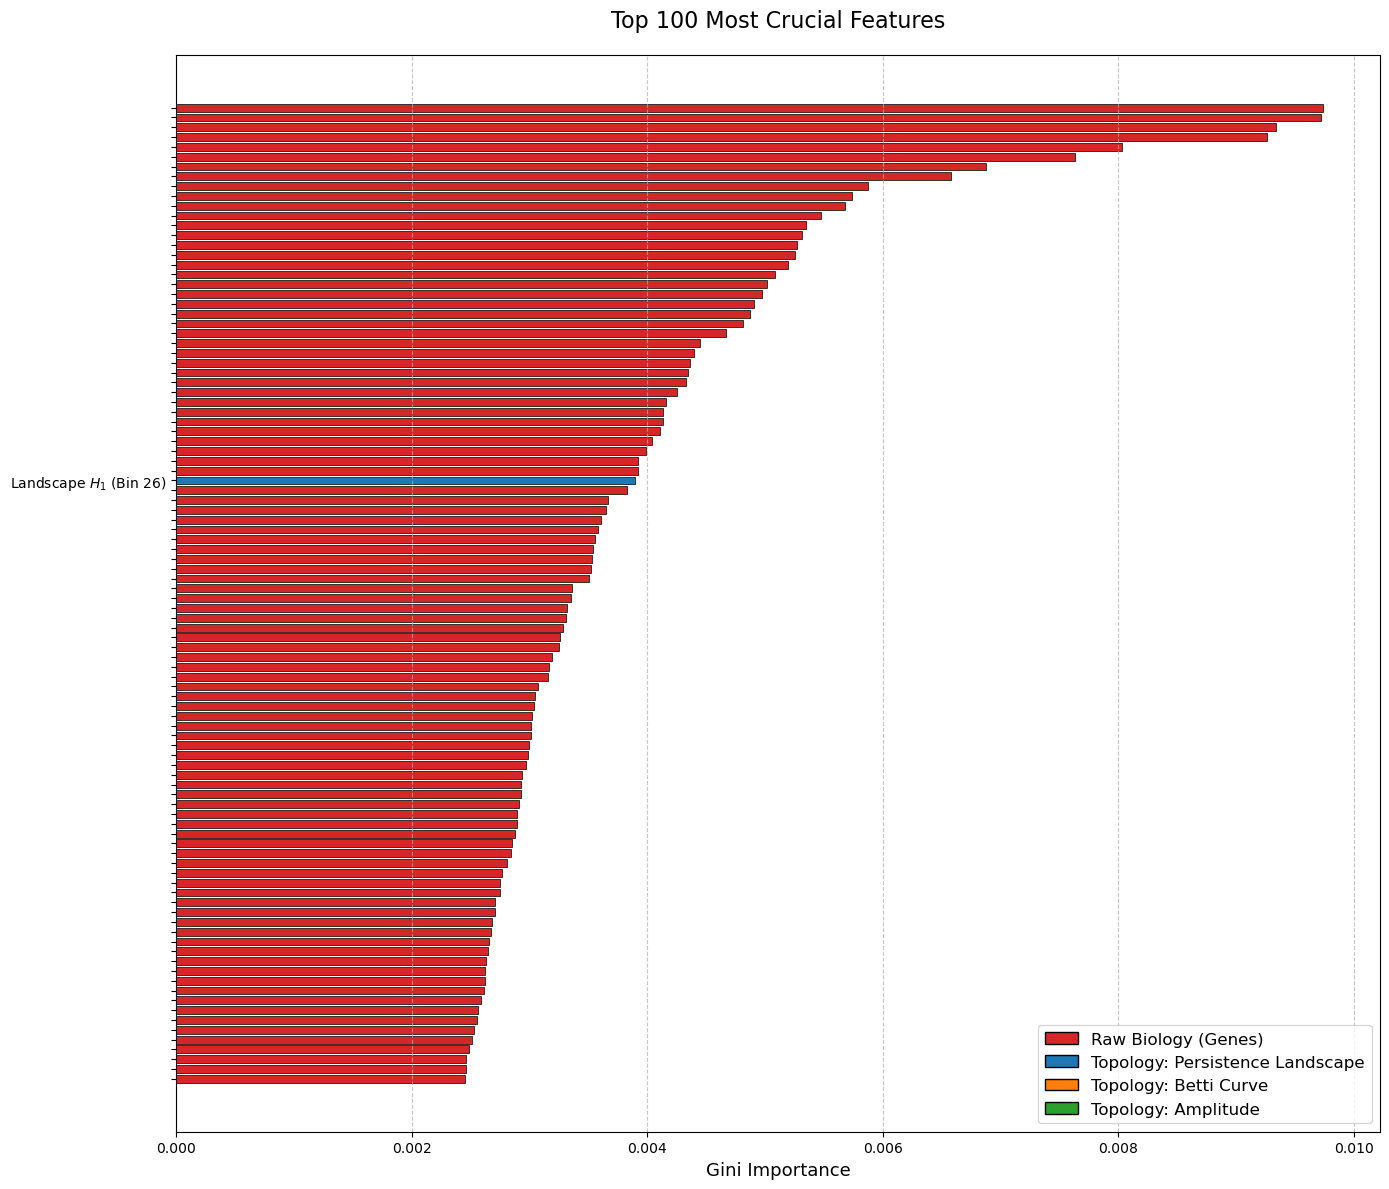

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

enriched_pipeline.fit(X, y_encoded)

rf_model = enriched_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

gene_names = [f"Selected Gene (ANOVA Rank {i+1})" for i in range(N_GENES)]
landscape_names = [f"Landscape $H_{h}$ (Bin {b+1})" for h in [0, 1] for b in range(50)]
amplitude_names = ["Amplitude $H_0$", "Amplitude $H_1$"]
betti_names = [f"Betti Curve $H_{h}$ (Bin {b+1})" for h in [0, 1] for b in range(50)]

tda_names = landscape_names + amplitude_names + betti_names
feature_names = np.array(gene_names + tda_names)

assert len(importances) == len(feature_names), f"Mismatch: {len(importances)} importances vs {len(feature_names)} names."

top_n = 100 
indices = np.argsort(importances)[::-1][:top_n]
top_importances = importances[indices]
top_names = feature_names[indices]

display_names = []
for name in top_names:
    if "Landscape" in name or "Betti" in name or "Amplitude" in name:
        display_names.append(name)
    else:
        display_names.append("")

plt.figure(figsize=(14, 12)) 

colors = []
for name in top_names:
    if "Landscape" in name:
        colors.append('#1f77b4')
    elif "Betti" in name:
        colors.append('#ff7f0e')
    elif "Amplitude" in name:
        colors.append('#2ca02c')
    else:
        colors.append('#d62728')

bars = plt.barh(range(top_n), top_importances[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)

plt.yticks(range(top_n), display_names[::-1], fontsize=10)
plt.xlabel('Gini Importance', fontsize=13)
plt.title(f'Top {top_n} Most Crucial Features', fontsize=16, pad=20)

legend_elements = [
    Patch(facecolor='#d62728', edgecolor='black', label='Raw Biology (Genes)'),
    Patch(facecolor='#1f77b4', edgecolor='black', label='Topology: Persistence Landscape'),
    Patch(facecolor='#ff7f0e', edgecolor='black', label='Topology: Betti Curve'),
    Patch(facecolor='#2ca02c', edgecolor='black', label='Topology: Amplitude')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'BreastCancer_plots/{N_A_GENES}_{top_n}_feature_importances_{N_GENES}genes.png', dpi=300)
plt.show()

Wczytywanie prawdziwych danych z CuMiDa...
Budowanie mapy korelacji dla 1000 genów...
Rysowanie chmury punktów dla pacjenta 13 (Podtyp: basal)...


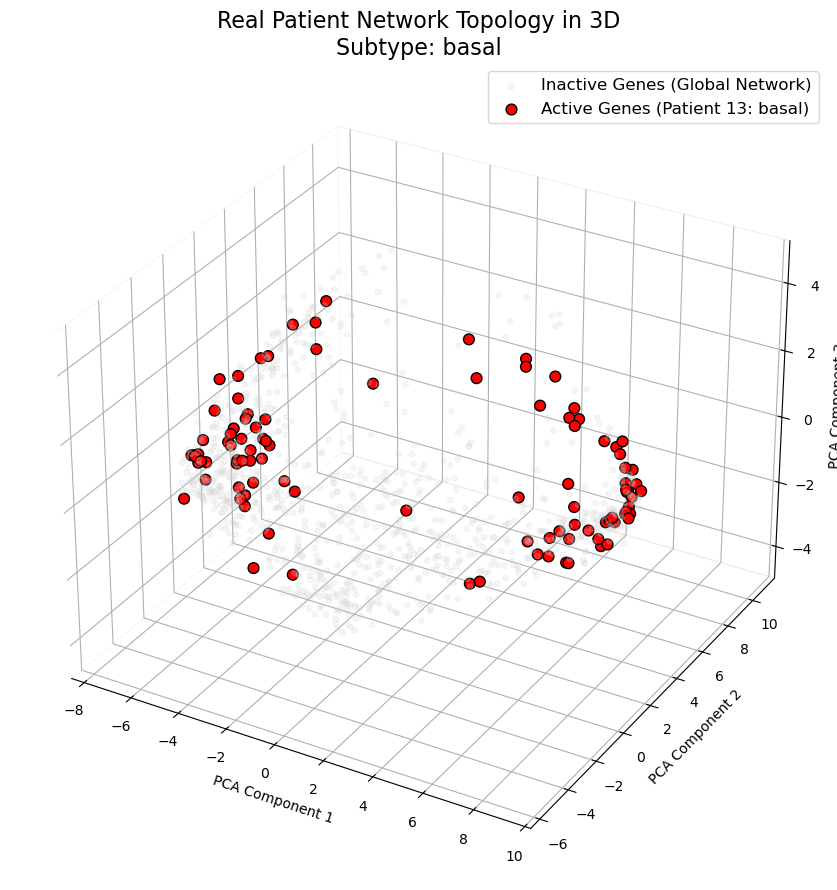

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

N_GENES = 1000
N_ACTIVE = 100

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_selected = selector.fit_transform(X_scaled, y)


corr = np.corrcoef(X_selected.T + np.random.normal(0, 1e-8, X_selected.T.shape))
corr = np.nan_to_num(corr, nan=0.0)
dist_matrix = 1 - np.abs(corr)

pca = PCA(n_components=3, random_state=42)
global_coords = pca.fit_transform(dist_matrix)


patient_idx = 13
patient_class = y[patient_idx]
patient_data = X_selected[patient_idx]

active_indices = np.argsort(patient_data)[-N_ACTIVE:]
patient_cloud = global_coords[active_indices]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

inactive_mask = np.ones(N_GENES, dtype=bool)
inactive_mask[active_indices] = False

ax.scatter(global_coords[inactive_mask, 0], 
           global_coords[inactive_mask, 1], 
           global_coords[inactive_mask, 2], 
           c='lightgray', alpha=0.2, s=15, label='Inactive Genes (Global Network)')

ax.scatter(patient_cloud[:, 0], 
           patient_cloud[:, 1], 
           patient_cloud[:, 2], 
           c='red', alpha=1.0, s=60, edgecolors='black', 
           label=f'Active Genes (Patient {patient_idx}: {patient_class})')

ax.set_title(f"Real Patient Network Topology in 3D\nSubtype: {patient_class}", fontsize=16)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.legend(fontsize=12)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/patient_{patient_idx}_3D_topology_subtype_{patient_class}.png', dpi=300)
plt.show()